In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv("uber.csv")
print(data.head())

   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647                1  
3         

In [16]:
data = data.dropna()
data = data[data['fare_amount'] > 0]

In [17]:
def calculate_distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

data['distance'] = calculate_distance(
    data['pickup_latitude'],
    data['pickup_longitude'],
    data['dropoff_latitude'],
    data['dropoff_longitude']
)

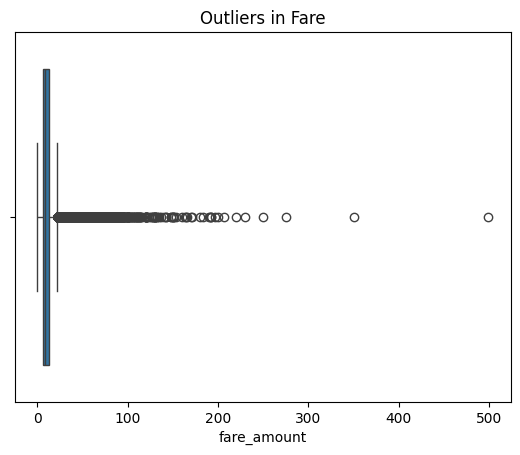

In [18]:
sns.boxplot(x=data['fare_amount'])
plt.title("Outliers in Fare")
plt.show()

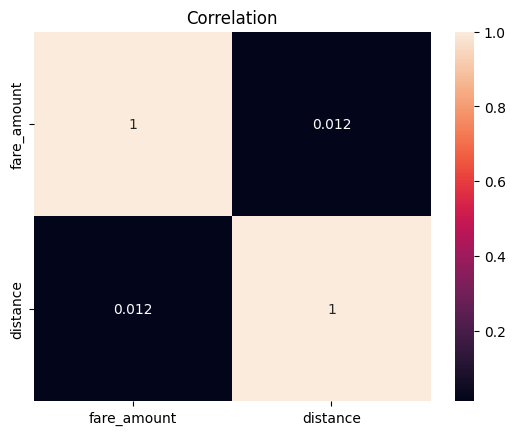

In [9]:
sns.heatmap(data[['fare_amount','distance']].corr(), annot=True)
plt.title("Correlation")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = data[['distance']]
y = data['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression -> RMSE:", rmse_lr, "R2:", r2_lr)
print("Random Forest -> RMSE:", rmse_rf, "R2:", r2_rf)

Linear Regression -> RMSE: 9.611621207880471 R2: 0.00013441139206304964
Random Forest -> RMSE: 5.611815488042724 R2: 0.6591564385158747


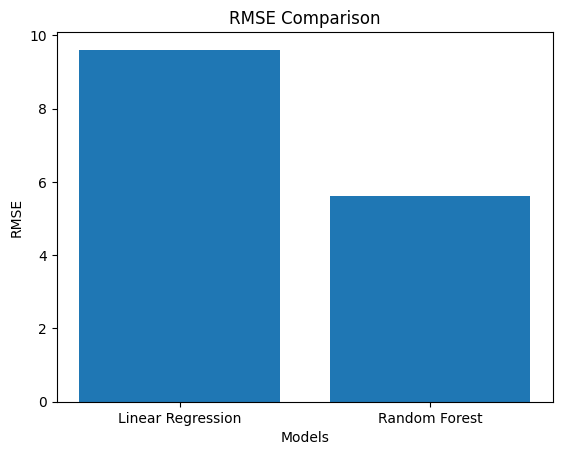

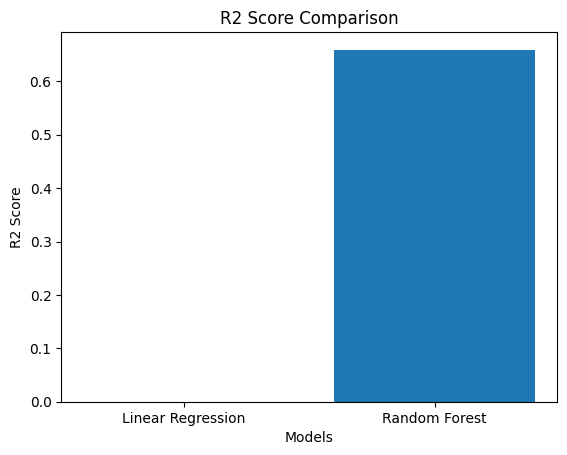

In [14]:
import matplotlib.pyplot as plt

# Model names
models = ['Linear Regression', 'Random Forest']

# Metrics
rmse_values = [rmse_lr, rmse_rf]
r2_values = [r2_lr, r2_rf]

# Plot RMSE comparison
plt.figure()
plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()

# Plot R2 comparison
plt.figure()
plt.bar(models, r2_values)
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

In [15]:
if r2_rf > r2_lr:
    print("Random Forest is better")
else:
    print("Linear Regression is better")

Random Forest is better
